# **EMPLOYEE TURNOVER ANALYTICS PROJECT**

## **Project Report – Portobello Tech Employee Turnover Prediction and Retention Strategy**

## **Prepared by: Avinash Kumar Jha**


## **Tools Used:**

  ***GoogleColab, python, Numpy, Pandas, Matplotlib, Seaborn, Scikit-Learn, Kmeans, Imbalanced learn, StratifiedKFold,   LogisticRegression, RandomForestClassifier,  ClassificationReport, ConfusionMatrix***




**Employee Turnover Prediction Using Machine Learning**

The objective of this project is to analyze employee work-related data and build machine learning models to predict employee turnover.Employee turnover refers to employees leaving the organization. High turnover negatively impacts productivity, increases hiring costs, and affects organizational performance.


**This project aims to**:

• Perform data quality

• Identify key factors influencing employee turnover using Exploratory Data Analysis (EDA)

• Cluster employees who left based on satisfaction and evaluation

• Handle class imbalance using SMOTE

• Train and evaluate multiple machine learning models

• Identify the best model using evaluation metrics

• Predict employee turnover probability

• Suggest retention strategies based on risk zones

**Dataset Description**

The dataset contains employee work-related information.


*LOAD DATASET into DATAFRAME*

In [1]:
import pandas as pd
df = pd.read_csv('HR_comma_sep.csv')
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


*Data Quality Check*

In [2]:
df.shape

(14999, 10)

In [3]:
df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'sales', 'salary'],
      dtype='object')

In [4]:
df = df.rename(columns={'sales': 'Department'})
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [5]:
#check for missing values
df.isnull().sum()

,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_montly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
Department,0
salary,0


*Data Exploration*

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [7]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [8]:
df['Department'].unique()

array(['sales', 'accounting', 'hr', 'technical', 'support', 'management',
       'IT', 'product_mng', 'marketing', 'RandD'], dtype=object)

In [9]:
df['salary'].unique()

array(['low', 'medium', 'high'], dtype=object)

***EXPLORATORY DATA ANALYSIS (EDA)***

The objective of Exploratory Data Analysis was to identify key factors influencing employee turnover by analyzing feature distributions, relationships, and patterns using statistical summaries and visualizations.

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

**Correlation Heatmap**

A correlation heatmap was generated to examine the relationship between numerical variables and employee turnover.



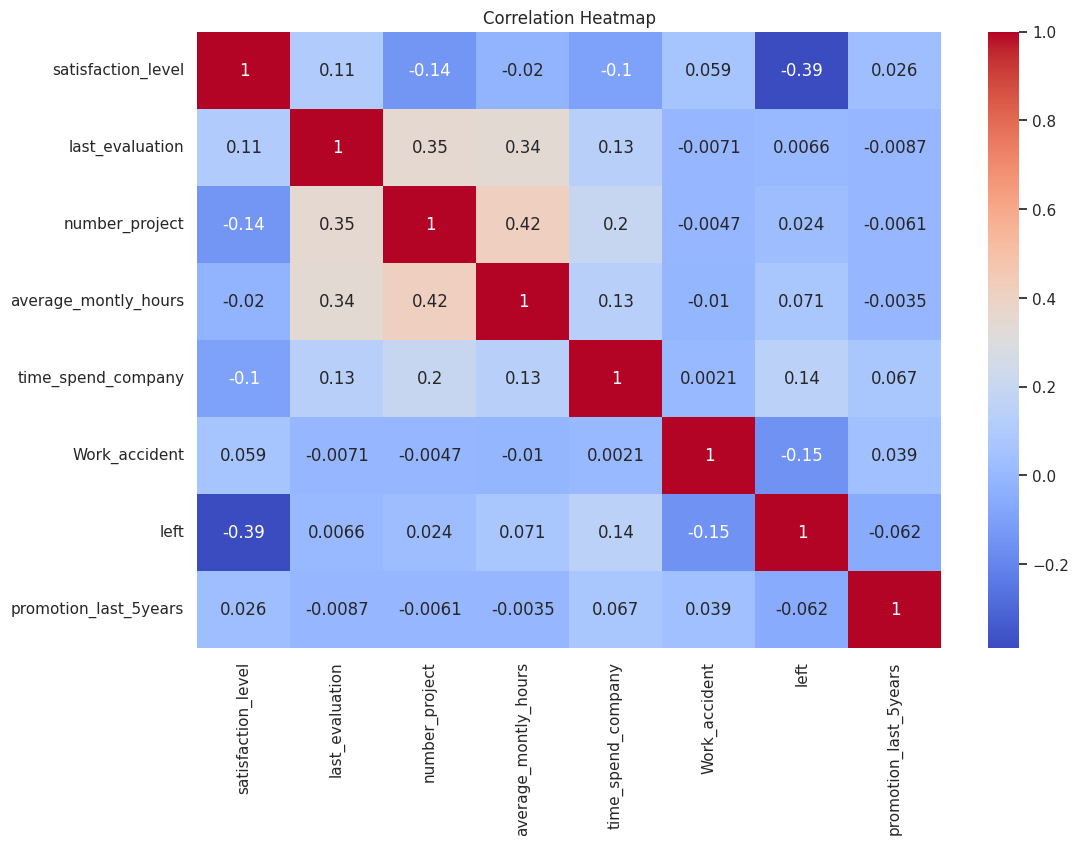

In [11]:
plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include=['int64','float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**Data Visualization**

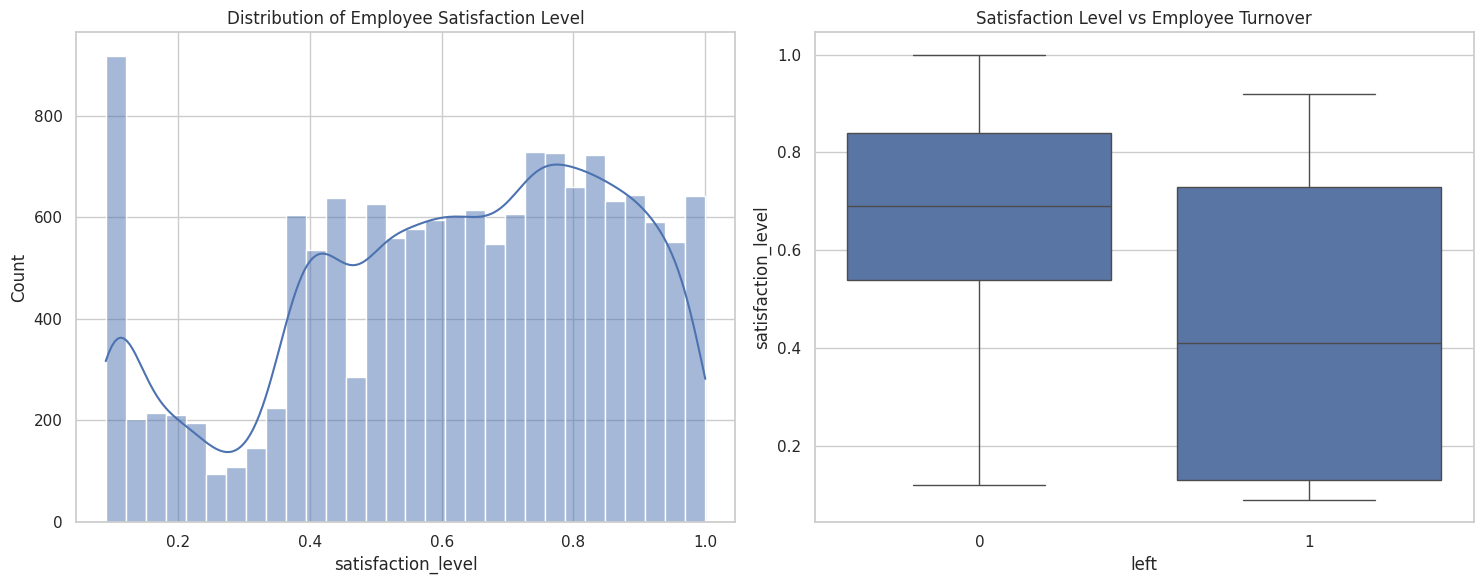

In [12]:
plt.figure(figsize=(15, 6))

# Subplot 1: Distribution of Employee Satisfaction Level (Histogram)
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(df['satisfaction_level'], kde=True)
plt.title("Distribution of Employee Satisfaction Level")

# Subplot 2: Satisfaction Level vs Employee Turnover (Boxplot)
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.boxplot(x='left', y='satisfaction_level', data=df)
plt.title("Satisfaction Level vs Employee Turnover")

plt.tight_layout()
plt.show()

**Graph:** Satisfaction Level vs Employee Turnover

**Report Insight:**

The boxplot comparing satisfaction level with employee turnover shows that employees who left the organization had significantly lower satisfaction levels than those who stayed. The median satisfaction for employees who stayed is around 0.68, whereas for those who left it is around 0.40. This indicates a strong relationship between employee dissatisfaction and attrition, suggesting that improving employee satisfaction could help reduce turnover.

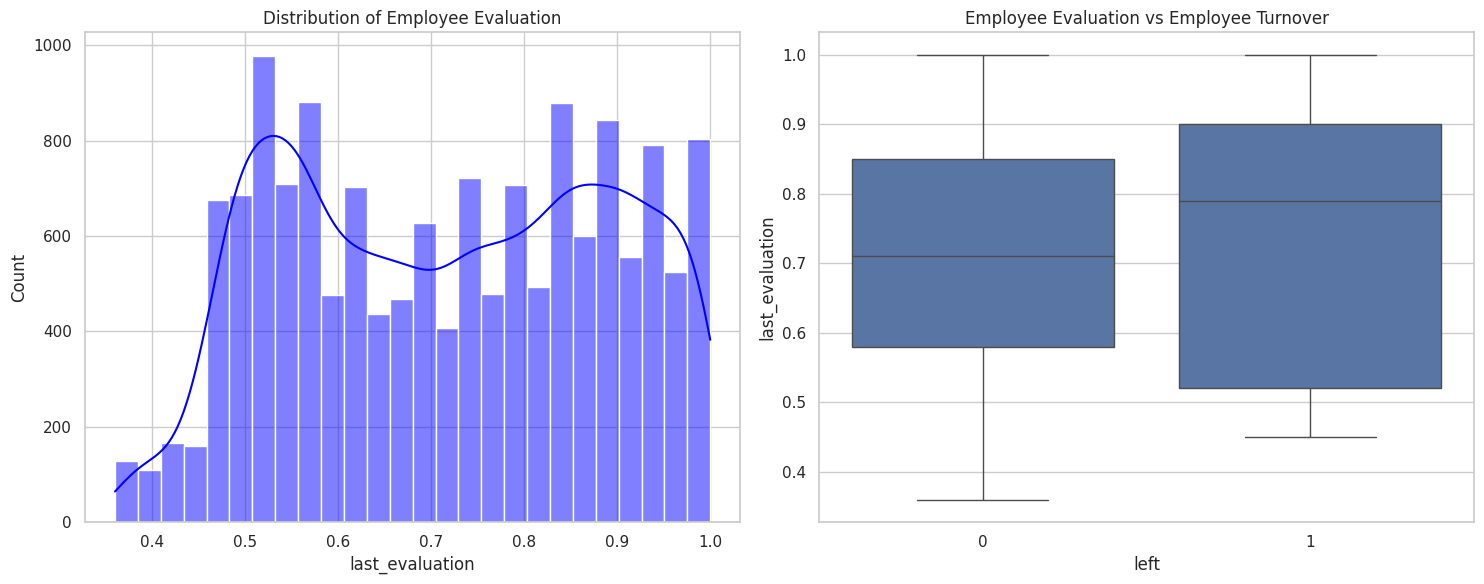

In [13]:
plt.figure(figsize=(15, 6))

# Subplot 1: Distribution of Employee Evaluation (Histogram)
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(df['last_evaluation'],color='blue', kde=True)
plt.title("Distribution of Employee Evaluation")

# Subplot 2: Employee Evaluation vs Employee Turnover (Boxplot)
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.boxplot(x='left', y='last_evaluation', data=df)
plt.title("Employee Evaluation vs Employee Turnover")

plt.tight_layout()
plt.show()

**Graph:** Employee Evaluation vs Employee Turnover

**Report Insight:**

> The boxplot shows that employees who left the company generally had slightly higher last evaluation scores compared to those who stayed. This suggests that even well-performing employees may leave the organization, possibly due to factors such as workload, career growth opportunities, or job satisfaction.


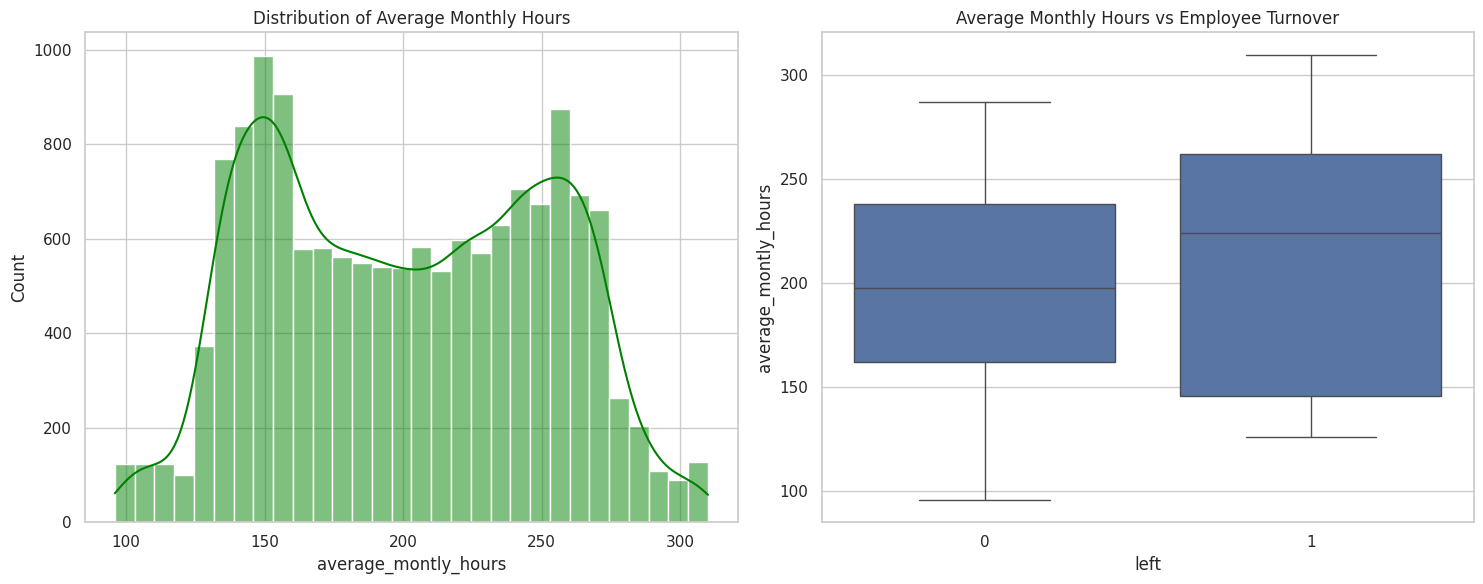

In [14]:
plt.figure(figsize=(15, 6))

# Subplot 1: Distribution of Average Monthly Hours (Histogram)
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(df['average_montly_hours'],color='green', kde=True)
plt.title("Distribution of Average Monthly Hours")

# Subplot 2: Average Monthly Hours vs Employee Turnover (Boxplot)
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.boxplot(x='left', y='average_montly_hours', data=df)
plt.title("Average Monthly Hours vs Employee Turnover")

plt.tight_layout()
plt.show()

**Graph:** Average Monthly Hours vs Employee Turnover

**Report Insight:**

> The boxplot indicates that employees who left the company tend to have higher average monthly working hours compared to those who stayed. This suggests that excessive workload may be a contributing factor to employee turnover.


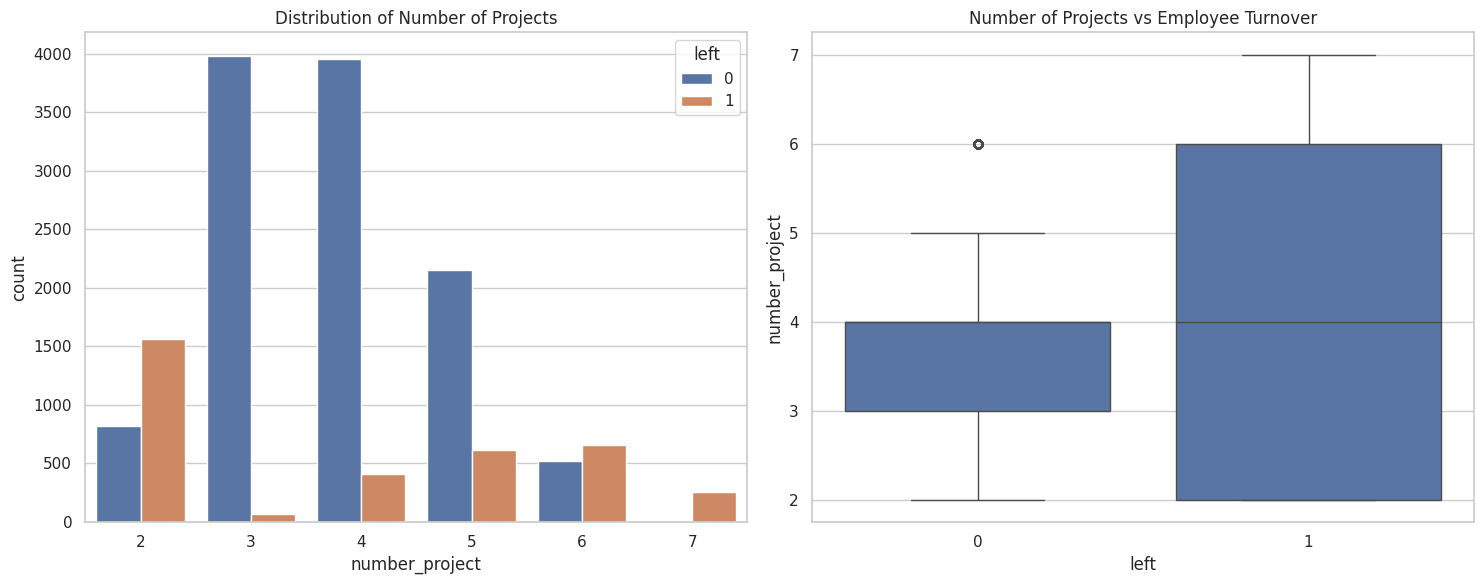

In [15]:
plt.figure(figsize=(15, 6))

# Subplot 1: Distribution of Number of Projects (Countplot)
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.countplot(x='number_project', hue= 'left', data=df)
plt.title("Distribution of Number of Projects")

# Subplot 2: Number of Projects vs Employee Turnover (Boxplot)
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.boxplot(x='left', y='number_project', data=df)
plt.title("Number of Projects vs Employee Turnover")

plt.tight_layout()
plt.show()

**Graph:** Number of Projects vs Employee Turnover

**Report Insight:**

> The boxplot shows that employees who left the company generally handled a wider range and often a higher number of projects compared to those who stayed. This suggests that excessive workload or project pressure may contribute to higher employee turnover.


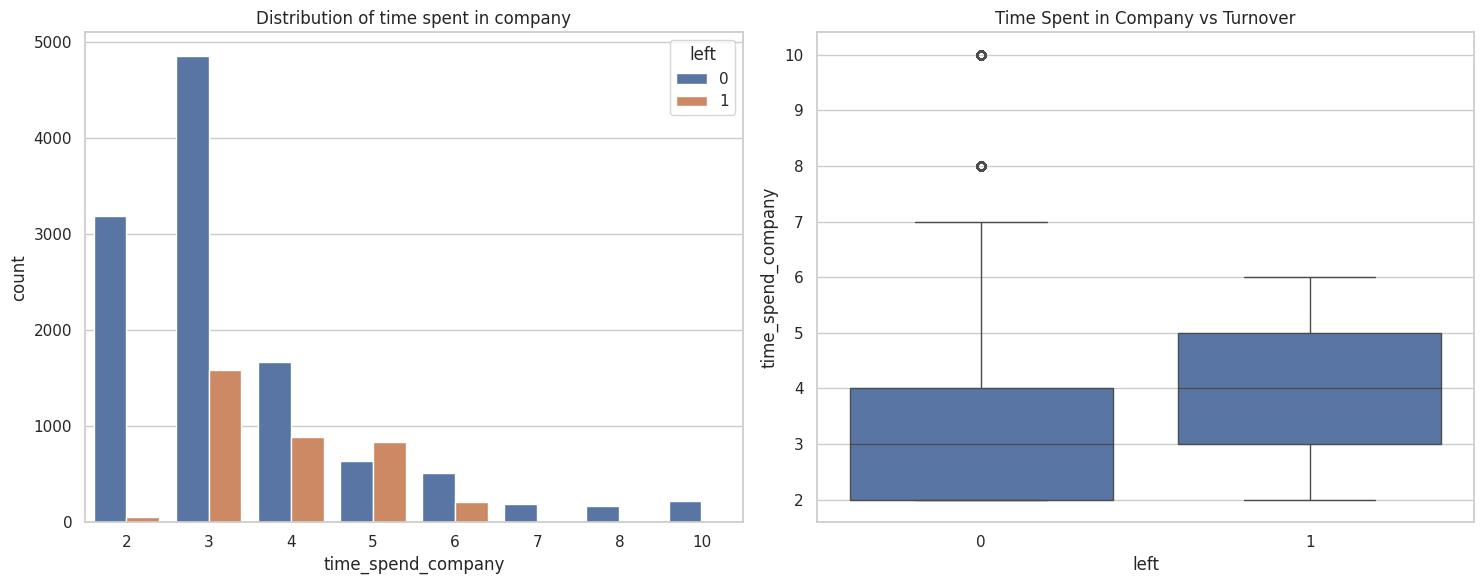

In [16]:
plt.figure(figsize=(15, 6))

# Subplot 1: Distribution of Number of Projects (Countplot)
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.countplot(x='time_spend_company', hue= 'left', data=df)
plt.title("Distribution of time spent in company")

# Subplot 2: Number of Projects vs Employee Turnover (Boxplot)
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.boxplot(x='left', y='time_spend_company', data=df)
plt.title("Time Spent in Company vs Turnover")

plt.tight_layout()
plt.show()

**Graph:** Time Spent in Company vs Employee Turnover

**Report Insight:**

> The boxplot indicates that employees who left the company generally had slightly higher tenure compared to those who stayed. This suggests that employees may be more likely to leave after spending several years in the organization, possibly due to limited growth opportunities or career progression.


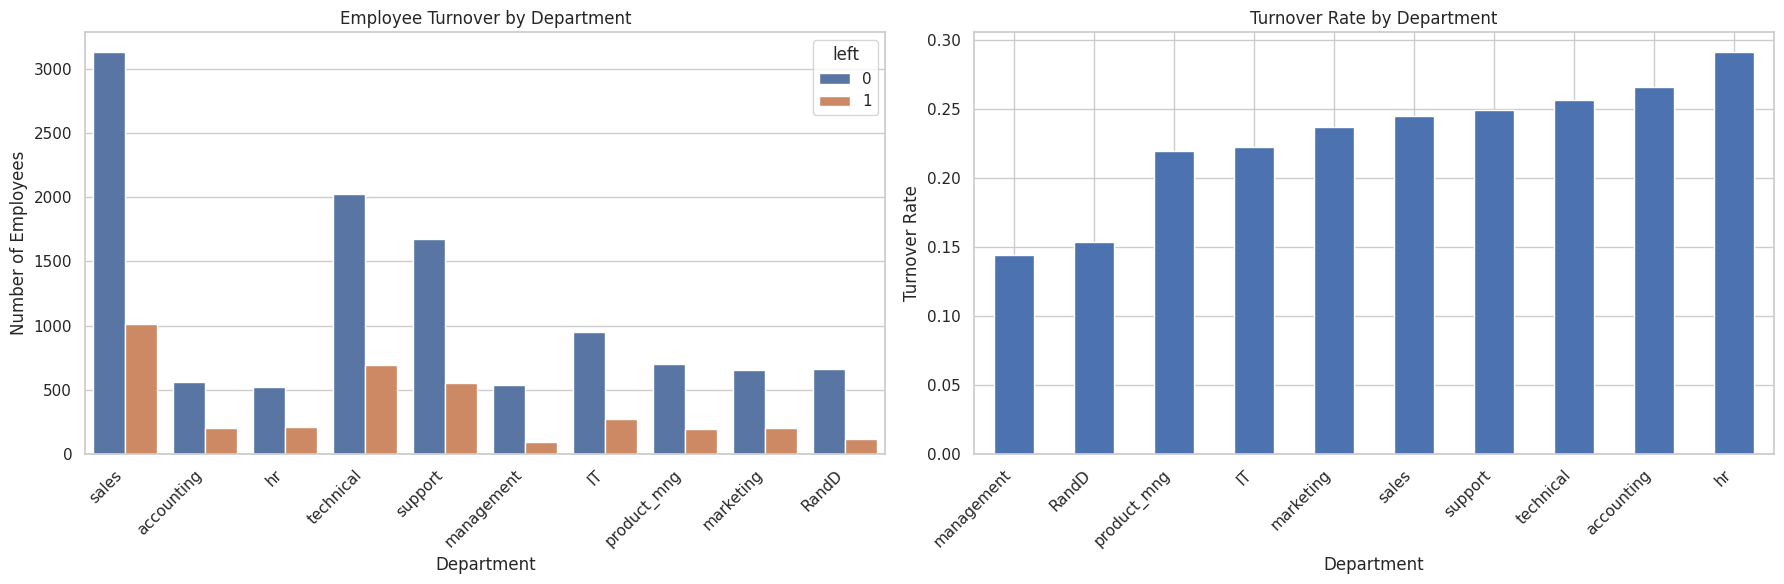

In [17]:
plt.figure(figsize=(18, 6))

# Subplot 1: Employee Turnover by Department (Countplot)
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.countplot(x='Department', hue='left', data=df)
plt.title("Employee Turnover by Department")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Number of Employees")

# Subplot 2: Turnover Rate by Department (Bar Plot)
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
dept_turnover = df.groupby('Department')['left'].mean().sort_values()
dept_turnover.plot(kind='bar')
plt.title("Turnover Rate by Department")
plt.ylabel("Turnover Rate")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

**Graph:** Employee Turnover by Department & Turnover Rate by Department

**Report Insight:**

> The visualization shows that the Sales department has the highest number of employees leaving due to its larger workforce size, while departments such as HR and Accounting exhibit relatively higher turnover rates proportionally. This indicates that employee attrition varies across departments and may be influenced by department-specific workload or job conditions.


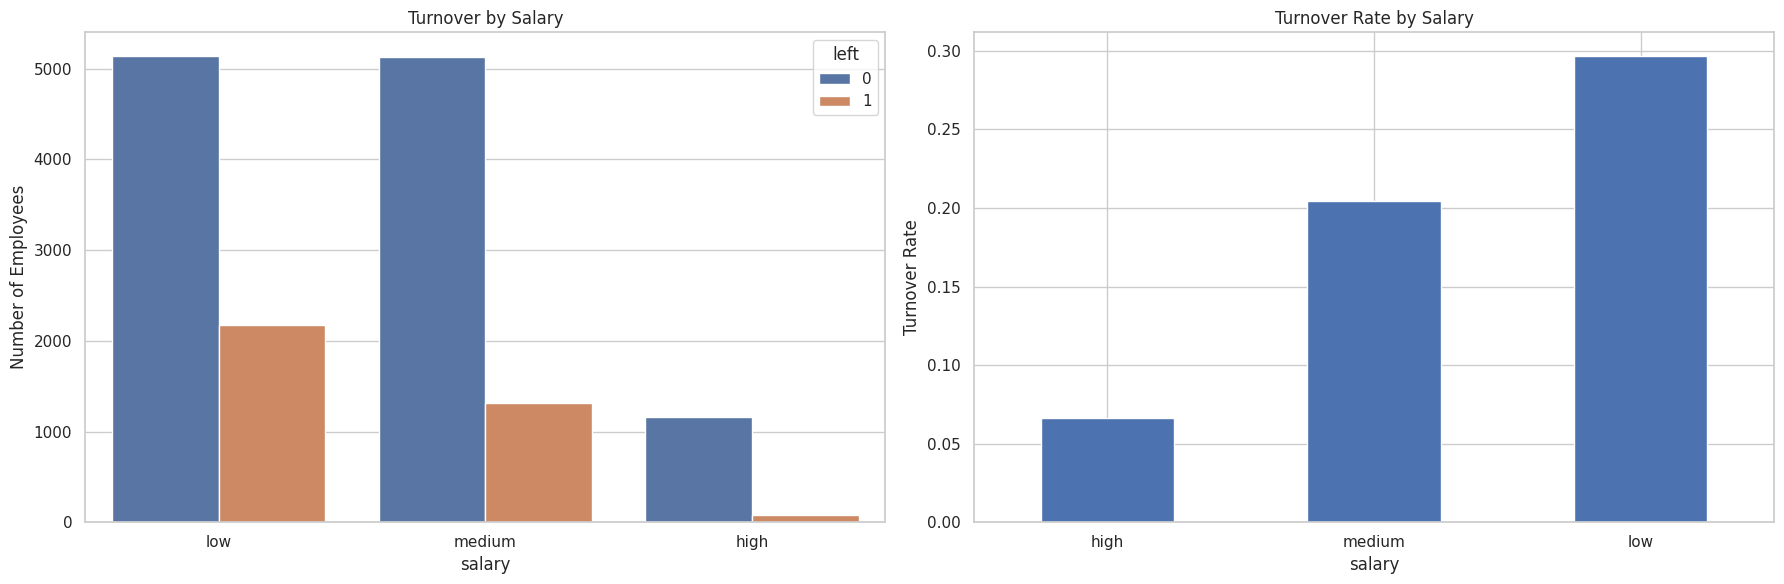

In [18]:
plt.figure(figsize=(18, 6))

# Subplot 1: Turnover by Salary (Countplot)
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.countplot(x='salary', hue='left', data=df)
plt.title("Turnover by Salary")
plt.ylabel("Number of Employees")

# Subplot 2: Turnover Rate by Salary (Bar Plot)
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
salary_turnover = df.groupby('salary')['left'].mean().sort_values()
salary_turnover.plot(kind='bar')
plt.title("Turnover Rate by Salary")
plt.ylabel("Turnover Rate")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

**Graph:** Employee Turnover by Salary & Turnover Rate by Salary

**Report Insight:**

> The visualization shows that employees with low salaries have the highest turnover rate, while employees with high salaries have the lowest turnover. This indicates that compensation plays a significant role in employee retention and job satisfaction.


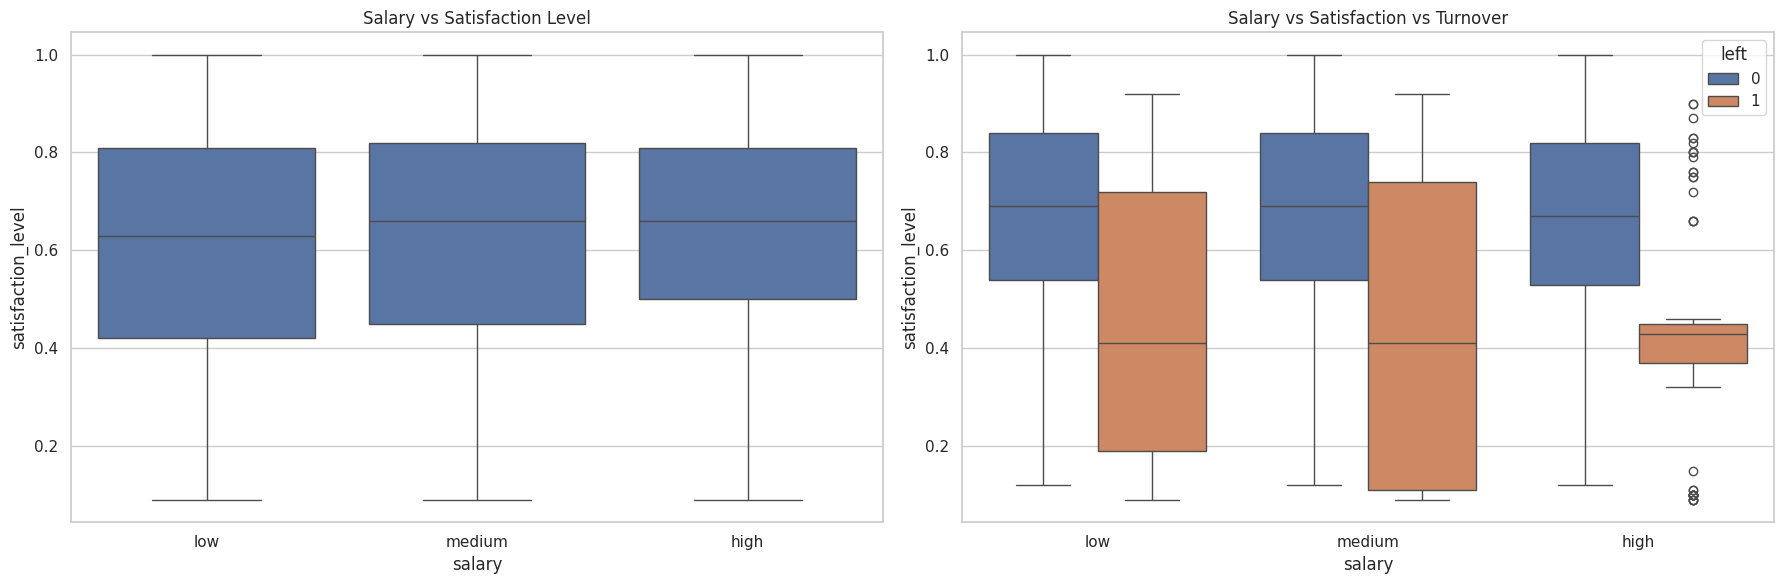

In [19]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x='salary', y='satisfaction_level', data=df)
plt.title("Salary vs Satisfaction Level")

plt.subplot(1, 2, 2)
sns.boxplot(x='salary', y='satisfaction_level', hue='left', data=df)
plt.title("Salary vs Satisfaction vs Turnover")

plt.tight_layout()
plt.show()


**Graph:** Salary vs Satisfaction Level & Salary vs Satisfaction vs Turnover

**Report Insight:**

> The visualization shows that satisfaction levels are relatively similar across salary categories; however, employees who left generally exhibit lower satisfaction levels across all salary groups. This indicates that employee satisfaction plays a more critical role in turnover than salary alone.


The salary column is an ordinal categorical variable with a natural order (low < medium < high). Therefore, manual label encoding using map() is being done instead of LabelEncoder to preserve the correct order.

In [20]:
salary_map = {
'low' : 0,
'medium' : 1,
'high' : 2
}
df['salary'] = df['salary'].map(salary_map)
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,0
1,0.80,0.86,5,262,6,0,1,0,sales,1
2,0.11,0.88,7,272,4,0,1,0,sales,1
3,0.72,0.87,5,223,5,0,1,0,sales,0
4,0.37,0.52,2,159,3,0,1,0,sales,0


Salary was encoded as an ordinal numerical variable and included in the correlation analysis. The heatmap shows a negative correlation between salary and employee turnover, indicating that employees with higher salary levels are less likely to leave.

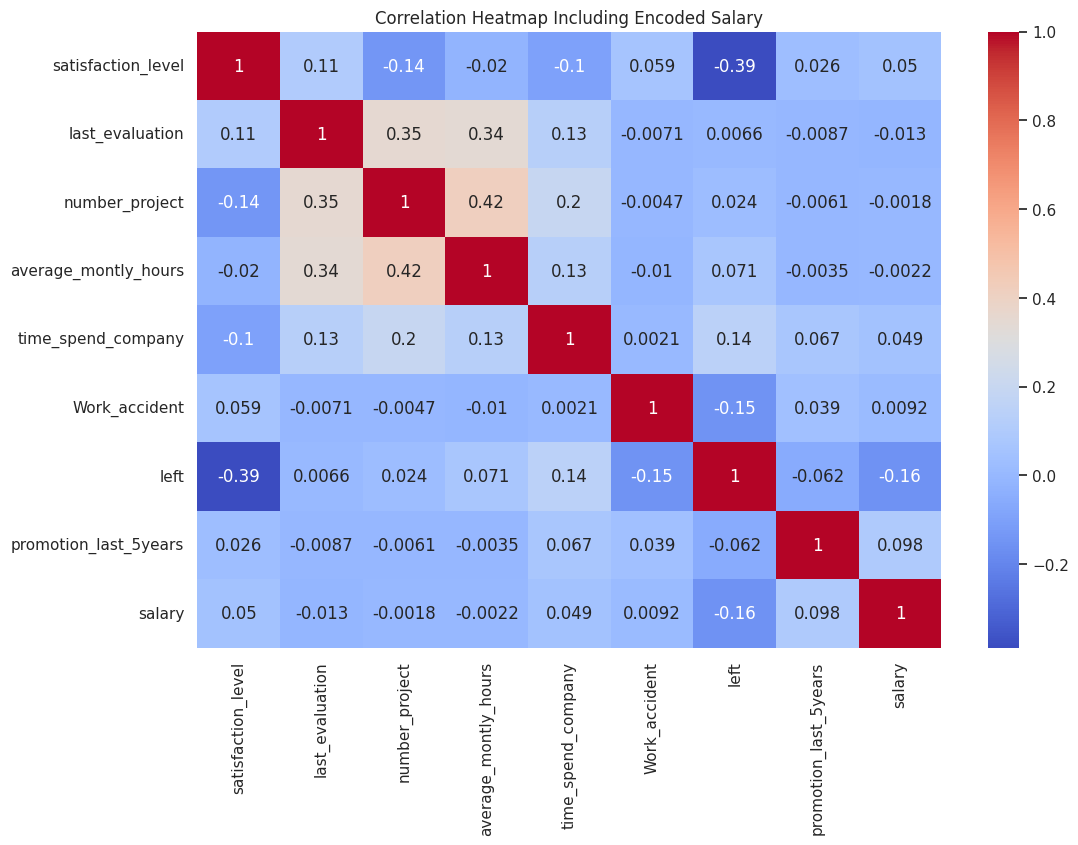

In [21]:
plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include=['int64','float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap Including Encoded Salary")
plt.show()


In [22]:
df_left = df[df.left==1].copy()
df_stayed = df[df.left==0].copy()
df_left.shape, df_stayed.shape

((3571, 10), (11428, 10))

In [23]:
df_left.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,0
1,0.80,0.86,5,262,6,0,1,0,sales,1
2,0.11,0.88,7,272,4,0,1,0,sales,1
3,0.72,0.87,5,223,5,0,1,0,sales,0
4,0.37,0.52,2,159,3,0,1,0,sales,0


In [24]:
X = df_left.loc[:, ['satisfaction_level', 'last_evaluation']]
X.head()

,satisfaction_level,last_evaluation
0,0.38,0.53
1,0.80,0.86
2,0.11,0.88
3,0.72,0.87
4,0.37,0.52


Text(0, 0.5, 'wcss')

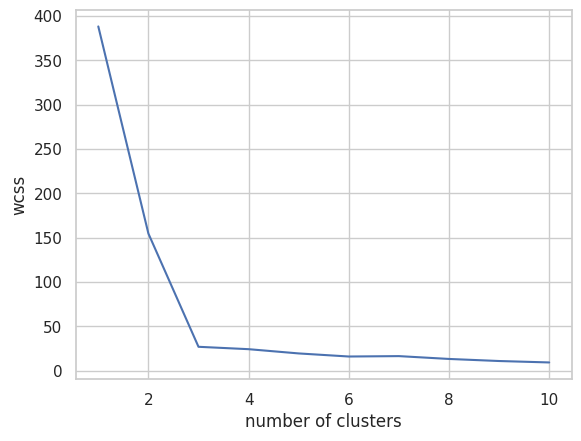

In [25]:
#elbow method
from sklearn.cluster import KMeans
wcss = []
for i in range(1,11):
    km = KMeans(n_clusters=i)
    km.fit(X)
    wcss.append(km.inertia_)

plt.plot(range(1,11),wcss)
plt.xlabel('number of clusters')
plt.ylabel('wcss')

In [26]:
km = KMeans(n_clusters=3, random_state=42)
df_left['cluster'] = km.fit_predict(X)
df_left.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary,cluster
0,0.38,0.53,2,157,3,0,1,0,sales,0,0
1,0.80,0.86,5,262,6,0,1,0,sales,1,1
2,0.11,0.88,7,272,4,0,1,0,sales,1,2
3,0.72,0.87,5,223,5,0,1,0,sales,0,1
4,0.37,0.52,2,159,3,0,1,0,sales,0,0


In [27]:
km.cluster_centers_

array([[0.41014545, 0.51698182],
       [0.80851586, 0.91170931],
       [0.11115466, 0.86930085]])

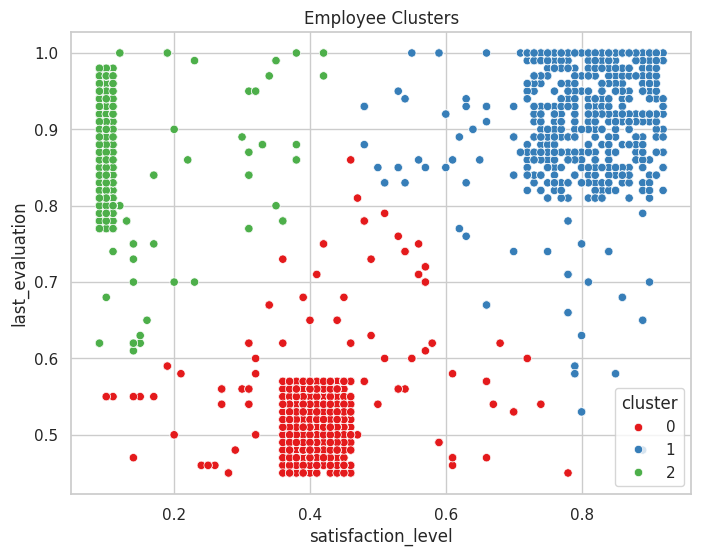

In [28]:
plt.figure(figsize=(8,6))

sns.scatterplot(
x='satisfaction_level',
y='last_evaluation',
hue='cluster',
data=df_left,
palette='Set1'
)
plt.title("Employee Clusters")
plt.show()

**Clustering Interpretation**

K-Means clustering was performed on employees who left the organization using satisfaction level and last evaluation score.

The analysis identified three distinct employee groups.

Cluster 0 consisted of employees with moderate satisfaction and low performance. These employees were likely disengaged and less productive.(Loosing them is less damaging.)

Cluster 1 consisted of employees with high satisfaction and high performance. These employees likely left for better career opportunities.
(Not always preventable.)

Cluster 2 consisted of employees with low satisfaction but high performance. This group represents overworked and dissatisfied employees. These employees are valuable to the organization but left due to workload and lack of motivation.

Among these groups, Cluster 2 represents the most critical retention risk because it includes high-performing employees who are dissatisfied. Retaining these employees should be a priority for the organization.

***FEATURE*** ***ENGINEERING***

In [29]:
df.dtypes

,0
satisfaction_level,float64
last_evaluation,float64
number_project,int64
average_montly_hours,int64
time_spend_company,int64
Work_accident,int64
left,int64
promotion_last_5years,int64
Department,object
salary,int64


In [30]:
df['Department'].unique()

array(['sales', 'accounting', 'hr', 'technical', 'support', 'management',
       'IT', 'product_mng', 'marketing', 'RandD'], dtype=object)

In [31]:
final = pd.get_dummies(df, columns=['Department'], drop_first=True, dtype=int)


In [32]:
final.head()


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,salary,Department_RandD,Department_accounting,Department_hr,Department_management,Department_marketing,Department_product_mng,Department_sales,Department_support,Department_technical
0,0.38,0.53,2,157,3,0,1,0,0,0,0,0,0,0,0,1,0,0
1,0.80,0.86,5,262,6,0,1,0,1,0,0,0,0,0,0,1,0,0
2,0.11,0.88,7,272,4,0,1,0,1,0,0,0,0,0,0,1,0,0
3,0.72,0.87,5,223,5,0,1,0,0,0,0,0,0,0,0,1,0,0
4,0.37,0.52,2,159,3,0,1,0,0,0,0,0,0,0,0,1,0,0


In [33]:
X = final.drop('left', axis=1)
y = final['left']

In [34]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=123,
    stratify=y
)

In [35]:
print(y_train.value_counts())

left
0    9142
1    2857
Name: count, dtype: int64


***Handling Class Imbalance Using SMOTE:***

The training dataset showed class imbalance, with significantly more employees staying than leaving. To address this, the SMOTE technique was applied to the training data to handle class imbalance and prevent data leakage. SMOTE generates synthetic samples of the minority class to balance the dataset. After applying SMOTE, both classes had equal representation, which improves the model's ability to learn patterns of employee turnover.The test data was kept unchanged to ensure unbiased model evaluation.

In [36]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=123, sampling_strategy=1.0)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [37]:
print(y_train.value_counts())
print(y_train_smote.value_counts())

left
0    9142
1    2857
Name: count, dtype: int64
left
0    9142
1    9142
Name: count, dtype: int64


After applying SMOTE, the class distribution became balanced with a 1:1 ratio. This ensures that the machine learning model learns both classes equally and improves its ability to predict employee turnover.

In [38]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report

In [39]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
y_pred_lr = cross_val_predict(lr, X_train_smote, y_train_smote, cv=skf)
print(classification_report(y_train_smote, y_pred_lr))

              precision    recall  f1-score   support

           0       0.81      0.77      0.79      9142
           1       0.78      0.82      0.80      9142

    accuracy                           0.79     18284
   macro avg       0.79      0.79      0.79     18284
weighted avg       0.79      0.79      0.79     18284



In [40]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
y_pred_rf = cross_val_predict(rf, X_train_smote, y_train_smote, cv=skf)
print(classification_report(y_train_smote, y_pred_rf))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      9142
           1       0.99      0.97      0.98      9142

    accuracy                           0.98     18284
   macro avg       0.98      0.98      0.98     18284
weighted avg       0.98      0.98      0.98     18284



In [41]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=123)
y_pred_gb = cross_val_predict(gb, X_train_smote, y_train_smote, cv=skf)
print(classification_report(y_train_smote, y_pred_gb))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96      9142
           1       0.97      0.94      0.96      9142

    accuracy                           0.96     18284
   macro avg       0.96      0.96      0.96     18284
weighted avg       0.96      0.96      0.96     18284



 cross_val_predict trains temporary models internally and does not leave a final trained model. We must fit the model separately before predicting on test data.

In [42]:
lr.fit(X_train_smote, y_train_smote)
y_test_pred_lr = lr.predict(X_test)

rf.fit(X_train_smote, y_train_smote)
y_test_pred_rf = rf.predict(X_test)

gb.fit(X_train_smote, y_train_smote)
y_test_pred_gb = gb.predict(X_test)

In [43]:
print('classification report for logistic regression\n',classification_report(y_test,y_test_pred_lr))

classification report for logistic regression
               precision    recall  f1-score   support

           0       0.91      0.76      0.83      2286
           1       0.50      0.77      0.61       714

    accuracy                           0.76      3000
   macro avg       0.71      0.76      0.72      3000
weighted avg       0.81      0.76      0.78      3000



In [44]:
print('classification report for Random Forest classifier\n',classification_report(y_test,y_test_pred_rf))

classification report for Random Forest classifier
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      2286
           1       0.97      0.98      0.98       714

    accuracy                           0.99      3000
   macro avg       0.98      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000



In [45]:
print('classification report for gradient boosting classifier\n',classification_report(y_test,y_test_pred_gb))

classification report for gradient boosting classifier
               precision    recall  f1-score   support

           0       0.98      0.97      0.98      2286
           1       0.92      0.94      0.93       714

    accuracy                           0.96      3000
   macro avg       0.95      0.95      0.95      3000
weighted avg       0.96      0.96      0.96      3000



**ROC Curve and AUC Score**

In [46]:
#ROC requires probabilities, not labels
lr_prob = lr.predict_proba(X_test)[:,1]
rf_prob = rf.predict_proba(X_test)[:,1]
gb_prob = gb.predict_proba(X_test)[:,1]

In [47]:
#Compute ROC Curve and AUC
from sklearn.metrics import roc_curve, roc_auc_score

lr_auc = roc_auc_score(y_test, lr_prob)
rf_auc = roc_auc_score(y_test, rf_prob)
gb_auc = roc_auc_score(y_test, gb_prob)

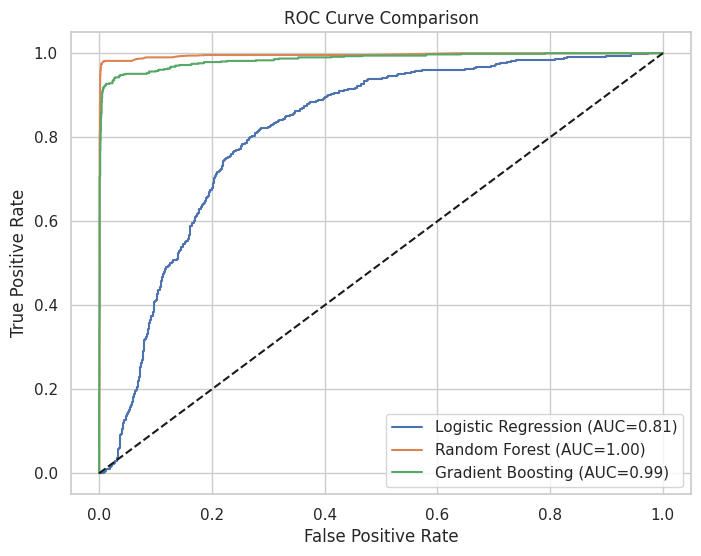

In [48]:
#plot ROC curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={lr_auc:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={rf_auc:.2f})")
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting (AUC={gb_auc:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()

*ROC/AUC Evaluation*

The ROC curve was plotted to compare the performance of the models. Random Forest achieved the highest AUC score, indicating superior ability to distinguish between employees who stay and those who leave.

*Confusion Matrix for Each Model* : Confusion matrix shows exact prediction counts

In [49]:
from sklearn.metrics import confusion_matrix

In [50]:
#logistic regression model
cm_lr = confusion_matrix(y_test, lr.predict(X_test))
cm_lr

array([[1741,  545],
       [ 167,  547]])

In [51]:
#random forest model
cm_rf = confusion_matrix(y_test, rf.predict(X_test))
cm_rf

array([[2268,   18],
       [  14,  700]])

In [52]:
#gradient boosting
cm_gb = confusion_matrix(y_test, gb.predict(X_test))
cm_gb

array([[2226,   60],
       [  46,  668]])

**Model Comparison**

Three models were trained and evaluated: Logistic Regression, Random Forest, and Gradient Boosting. Among these, Random Forest achieved the highest accuracy of 99% and recall score of 98% for predicting employee turnover. Recall is the most important metric in this project because it measures the model’s ability to correctly identify employees who will leave. Missing a potential employee turnover is more costly than incorrectly predicting that an employee may leave.

**Final Model Selection**

Based on:


*   Accurracy
*   Recall
*   AUC Score

***Best Model:***
Random Forest Classifier

### *Feature Importance Plot*

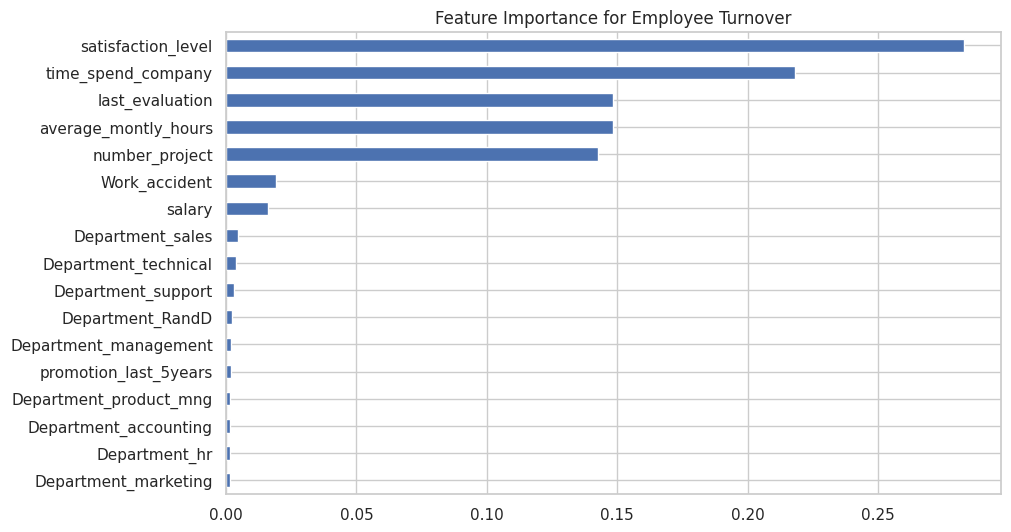

In [53]:
importances = rf.feature_importances_
feature_importance = pd.Series(importances, index=X_train.columns)
feature_importance.sort_values().plot(kind='barh', figsize=(10,6))
plt.title("Feature Importance for Employee Turnover")
plt.show()

**Categorize Employees into Risk Zones**

In [54]:
#predict probability of employee turnover
turnover_prob = rf.predict_proba(X_test)[:,1]

#add probabilities to test  data
test_results = X_test.copy()
test_results['Actual_Left'] = y_test
test_results['Turnover_Probability'] = turnover_prob

In [55]:
#create risk zones based on probabilities
def risk_zone(prob):
    if prob < 0.20:
        return "Safe Zone"
    elif prob < 0.60:
        return "Low Risk"
    elif prob < 0.90:
        return "Medium Risk"
    else:
        return "High Risk"
test_results['Risk_Zone'] = test_results['Turnover_Probability'].apply(risk_zone)

#check distribution of risk zones
test_results['Risk_Zone'].value_counts()

,count
Risk_Zone,
Safe Zone,2146
High Risk,657
Low Risk,147
Medium Risk,50


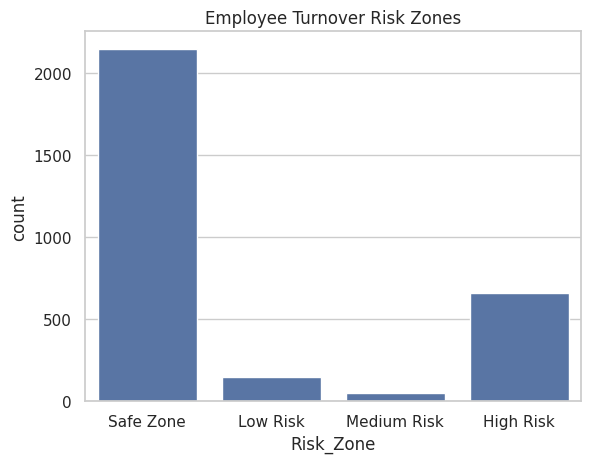

In [56]:
import seaborn as sns
sns.countplot(x='Risk_Zone', data=test_results,
              order=['Safe Zone','Low Risk','Medium Risk','High Risk'])

plt.title("Employee Turnover Risk Zones")
plt.show()

The machine learning model can identify employees at risk of leaving and categorize them into risk zones based on predicted probabilities. This enables HR departments to proactively implement targeted retention strategies, reducing employee attrition and improving workforce stability.

**Retention Strategies for Each Zone**

**Safe Zone (Probability < 20%):**

These employees are unlikely to leave.

***Strategy:***

Maintain engagement

Regular feedback sessions

Career development opportunities

Maintain satisfaction.

**Low Risk Zone (Probability 20% – 60%):**

These employees have moderate risk.

***Strategy:***

Monitor job satisfaction

Improve work-life balance

Offer skill development programs

**Medium Risk Zone (Probability 60% – 90%):**

These employees are likely to leave.

***Strategy:***

Manager intervention

Review workload

Provide recognition and incentives

**High Risk Zone (Probability > 90%):**

These employees are highly likely to leave.

***Strategy:***

Immediate HR intervention

Salary revision or promotion

Role redesign or workload adjustment

## **CONCLUSION:**

Using the Random Forest model, employee turnover probabilities were predicted and employees were categorized into four risk zones. Employees in the high-risk and medium-risk zones require immediate HR attention, while those in low-risk and safe zones should be monitored and engaged through regular development programs. This predictive approach enables proactive workforce management and reduces employee attrition.